In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../../"))

In [2]:
from desc import set_device
set_device("gpu")

In [3]:
import numpy as np
np.set_printoptions(linewidth=np.inf, precision=4, suppress=True, threshold=sys.maxsize)
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.graph_objects as go
import functools
import scipy

I like to have this import all for convenience,

In [4]:
import desc

from desc.basis import *
from desc.backend import *
from desc.compute import *
from desc.coils import *
from desc.equilibrium import *
from desc.examples import *
from desc.grid import *
from desc.geometry import *
from desc.io import *

from desc.objectives import *
from desc.objectives.objective_funs import *
from desc.objectives.getters import *
from desc.objectives.normalization import compute_scaling_factors
from desc.objectives.utils import *
from desc.optimize._constraint_wrappers import *

from desc.transform import Transform
from desc.plotting import *
from desc.optimize import *
from desc.perturbations import *
from desc.profiles import *
from desc.compat import *
from desc.utils import *
from desc.magnetic_fields import *

from desc.__main__ import main
from desc.vmec_utils import vmec_boundary_subspace
from desc.input_reader import InputReader
from desc.continuation import solve_continuation_automatic

print_backend_info()

DESC version=0.17.3+411.g8a54240a7c.
Using JAX backend: jax version=0.7.2, jaxlib version=0.7.2, dtype=float64.
Using device: NVIDIA GeForce RTX 4080 Laptop GPU (id=0), with 10.25 GB available memory.


# Compare W7-X variants shown in the Paper 

In [12]:
eq_org = load(f"./results/W7-X_output.h5")[-1]
eq_poi = load(f"./results/poincare-resolve-w7x.h5")
eq_poi_rs = load(f"./results/poincare-resolve-w7x-solved.h5")
eq_poi_rsc = load(f"./results/poincare-resolve-w7x-cold-solved.h5")
eqs = [eq_org, eq_poi, eq_poi_rs, eq_poi_rsc]
labels = ["Original", "Poincaré Solved", "Poincaré LCFS Solved warm", "Poincaré LCFS Solved cold"]
colors = ["C0", "C1", "C2", "C3"]

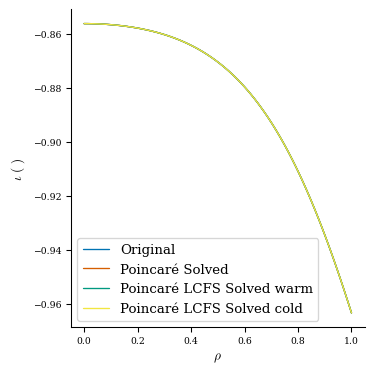

In [13]:
fig, ax = plot_1d(eq_org, "iota", label=labels[0], color=colors[0])
for eq in eqs[1:]:
    plot_1d(eq, "iota", ax=ax, label=labels[eqs.index(eq)], color=colors[eqs.index(eq)]);

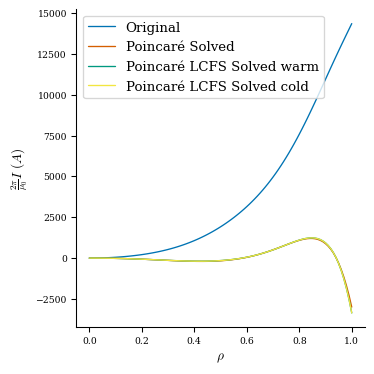

In [14]:
fig, ax = plot_1d(eq_org, "current", label=labels[0], color=colors[0])
for eq in eqs[1:]:
    plot_1d(eq, "current", ax=ax, label=labels[eqs.index(eq)], color=colors[eqs.index(eq)]);

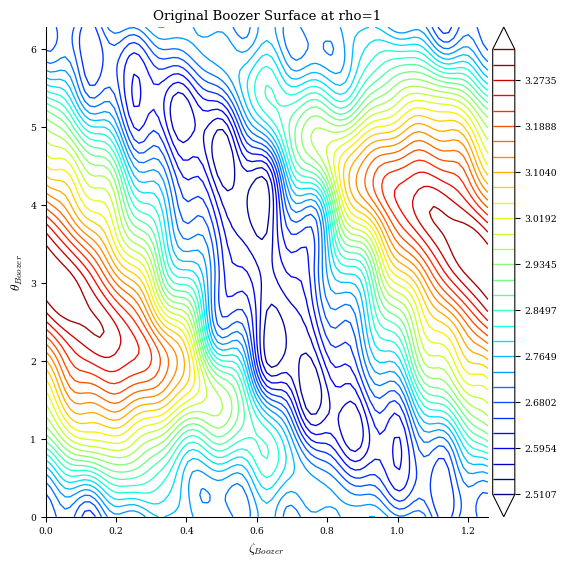

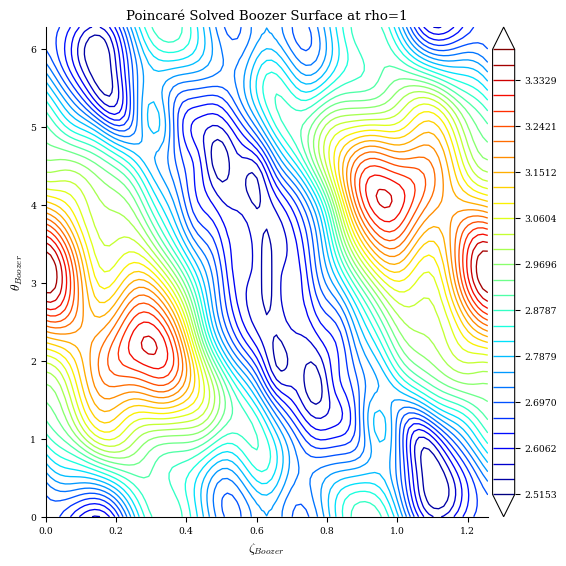

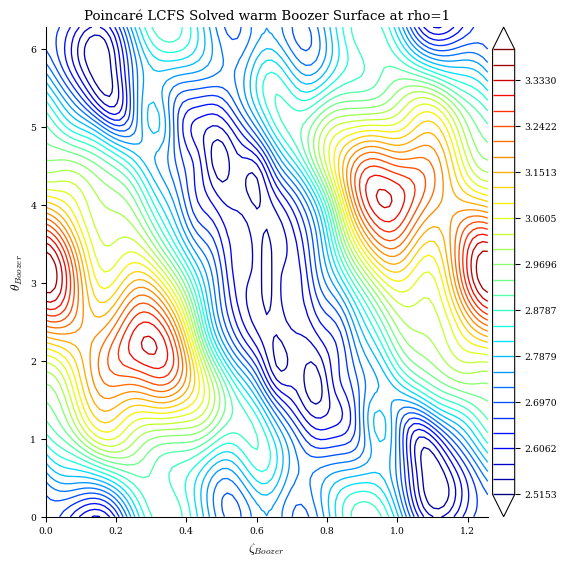

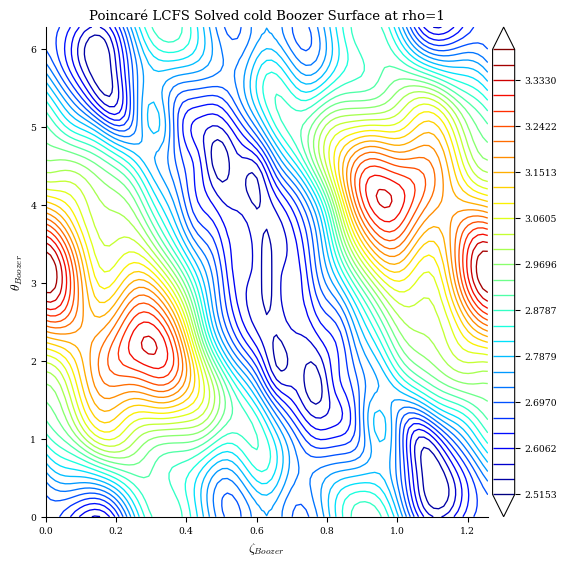

In [ ]:
for eq in eqs:
    fig, ax = plot_boozer_surface(eq, rho=1)
    ax.set_title(f"{labels[eqs.index(eq)]} Boozer Surface at rho=1")

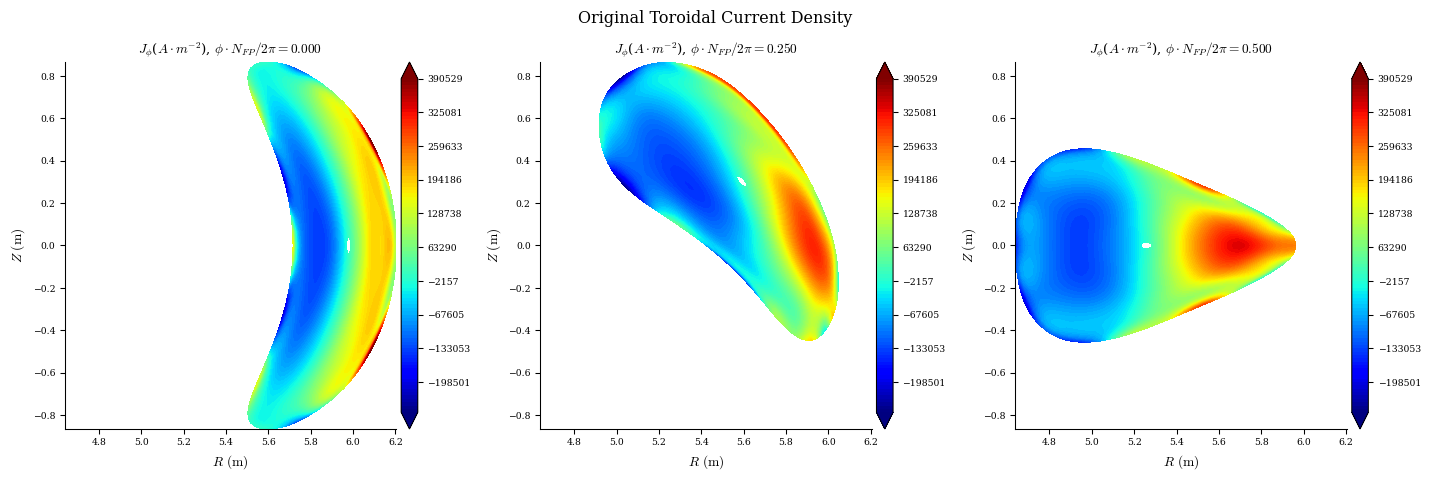

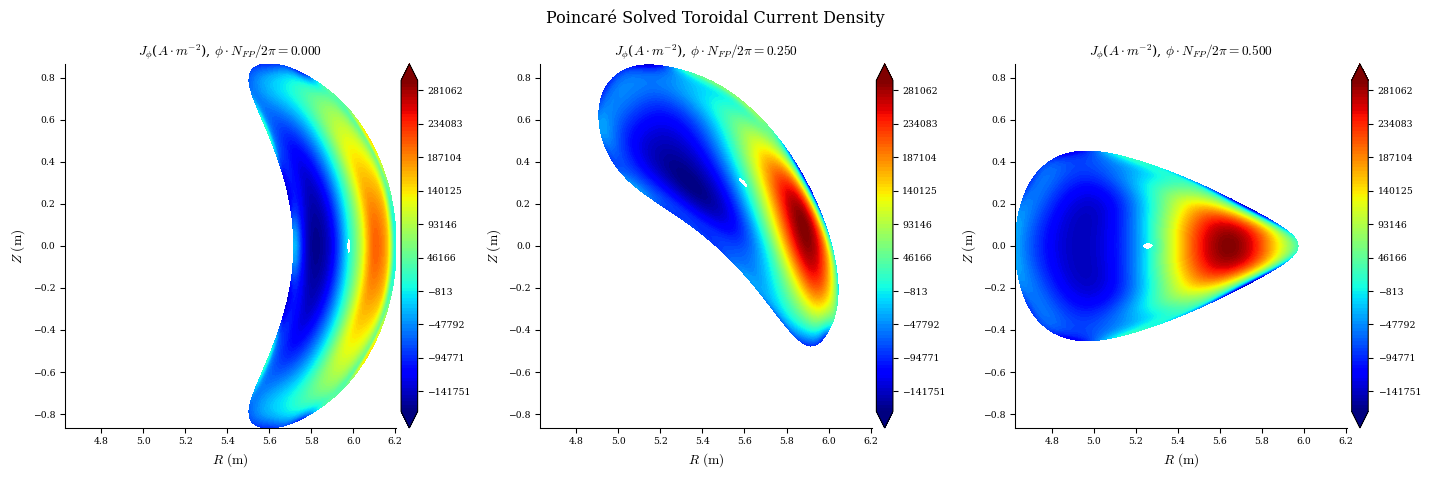

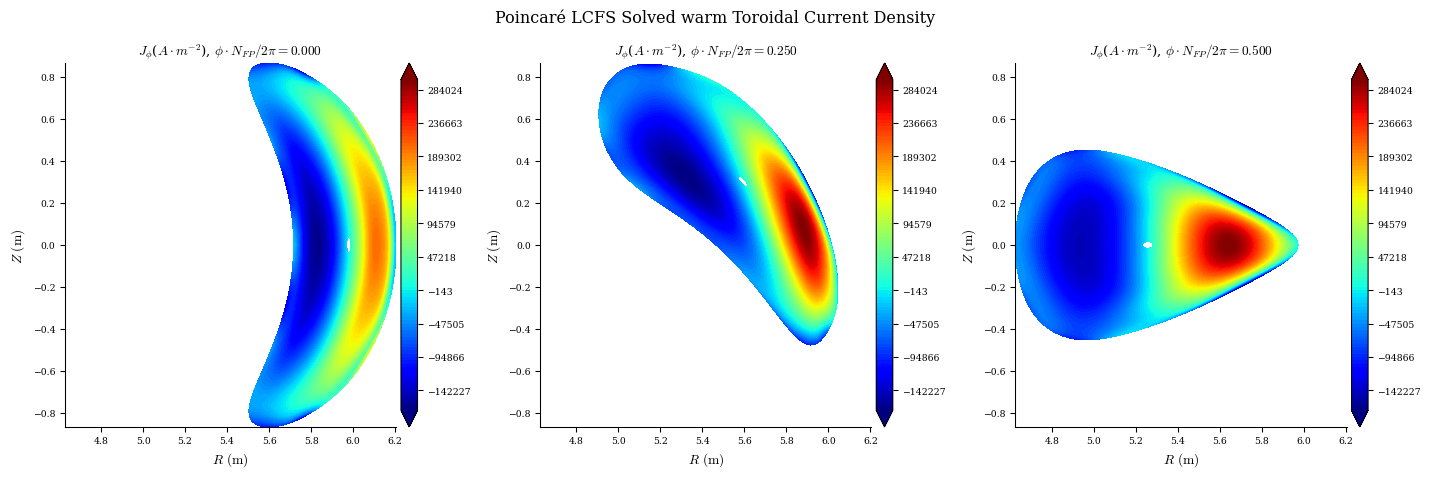

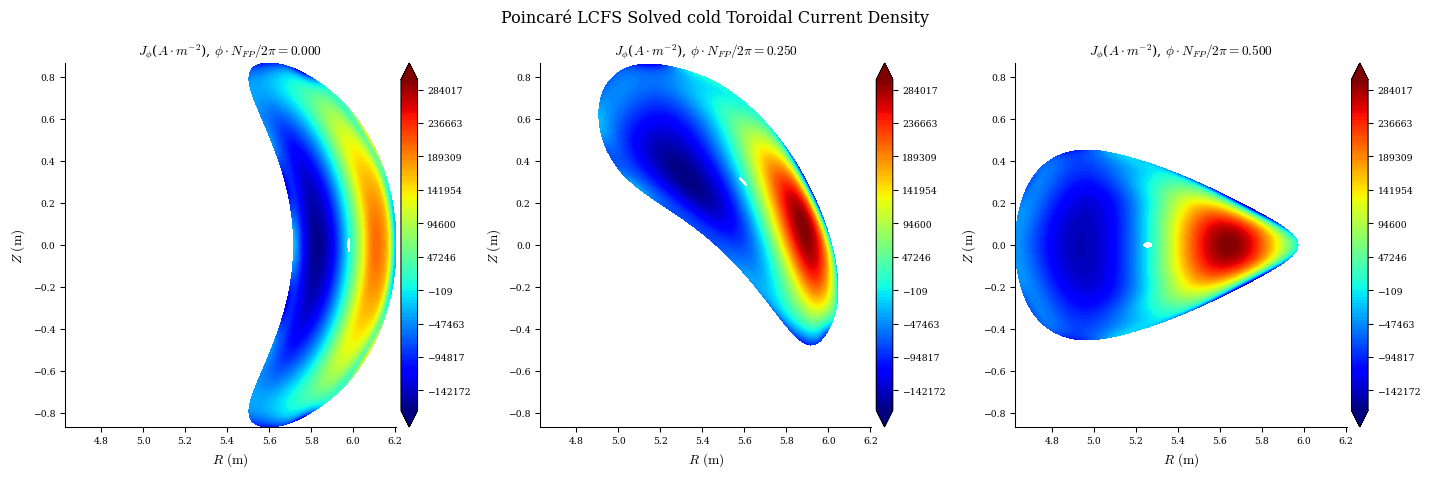

In [21]:
for eq in eqs:
    fig, ax = plot_section(eq, "J_phi", phi=np.linspace(0, np.pi / eq.NFP, 3, endpoint=True))
    fig.suptitle(f"{labels[eqs.index(eq)]} Toroidal Current Density")

# Compare Precise QH equivalent obtained in DESC and the QH result shown in Paper

In [5]:
L, M, N = 12, 12, 6
name = "wqs3-war3-wvol0"
folder = "../draft-images"
eq_poi = load(f"./results/Scan-QH-Paper-tight/eqfam-L{L}M{M}N{N}-{name}.h5")[-1]
eq_qh = load(f"./results/precise_QH_output.h5")[-1]
eq_qh2 = load(f"./results/equivalent_precise_QH_output.h5")[-1]
eq_qh3 = load(f"./results/normalized_qs_precise_QH_output.h5")[-1]
eqs = [eq_poi, eq_qh, eq_qh2, eq_qh3]
labels = ["Poincaré Optimized", "Precise QH", "Precise QH Equiv", "Precise QH Equiv norm QS"]
colors = ["C1", "C2", "C3", "C4"]

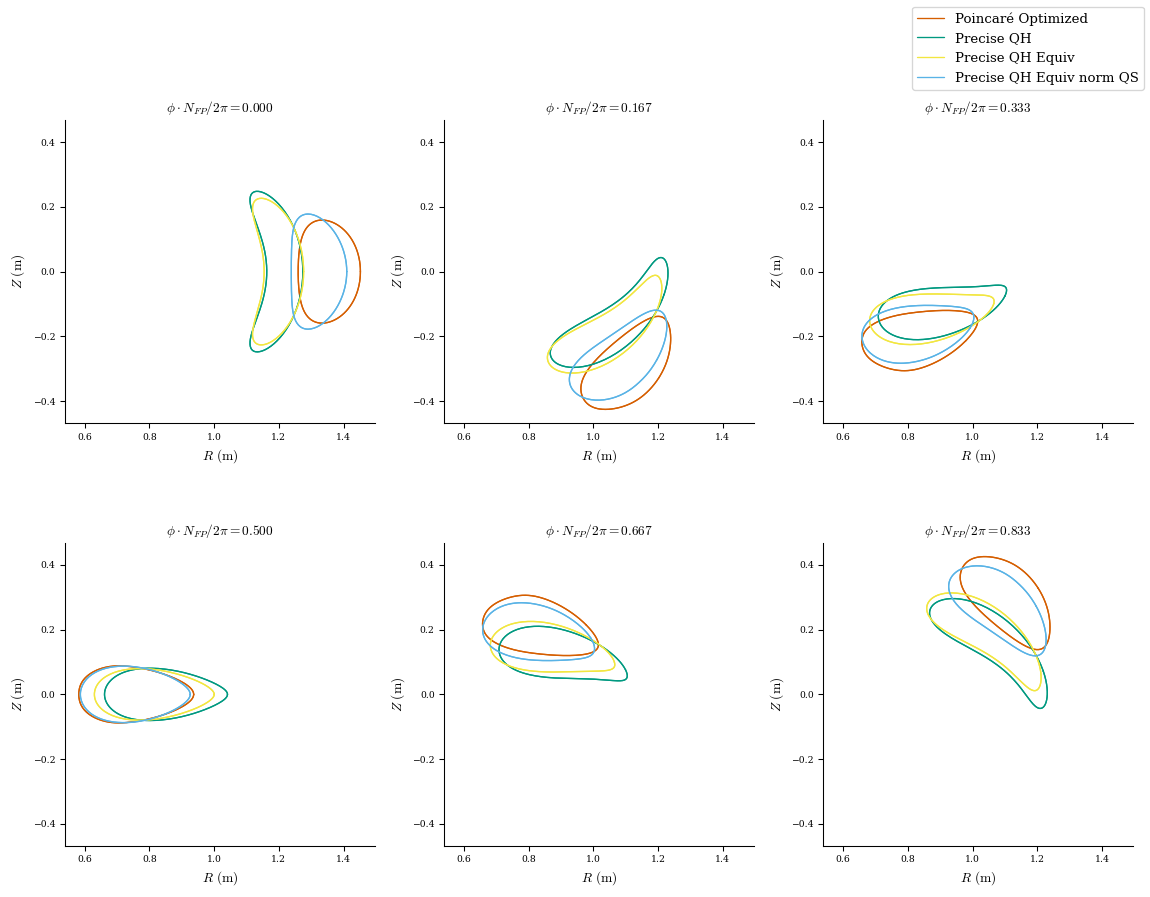

In [6]:
plot_comparison(eqs, labels=labels, color=colors, rho=np.array([1.0]), theta=0);

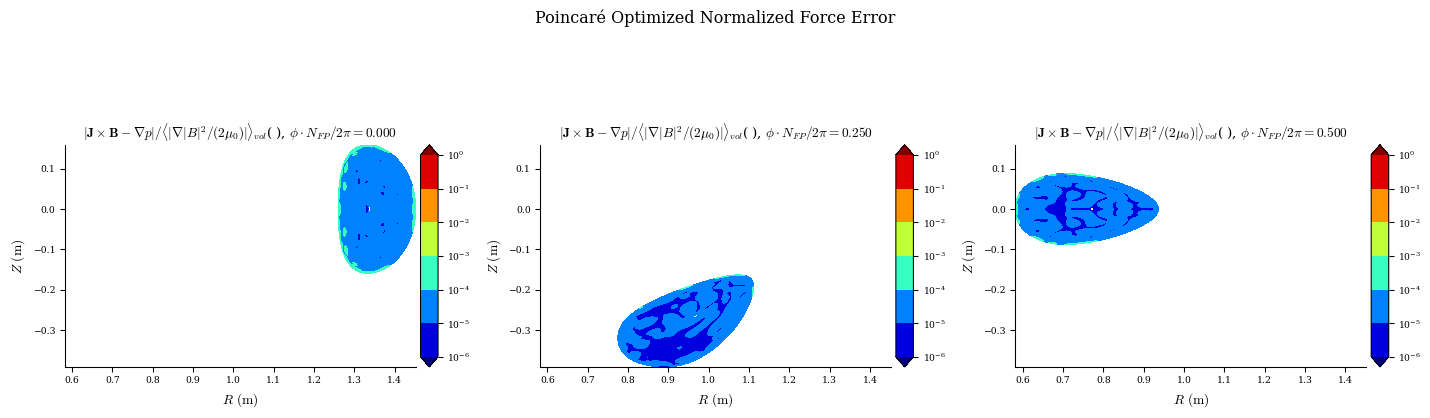

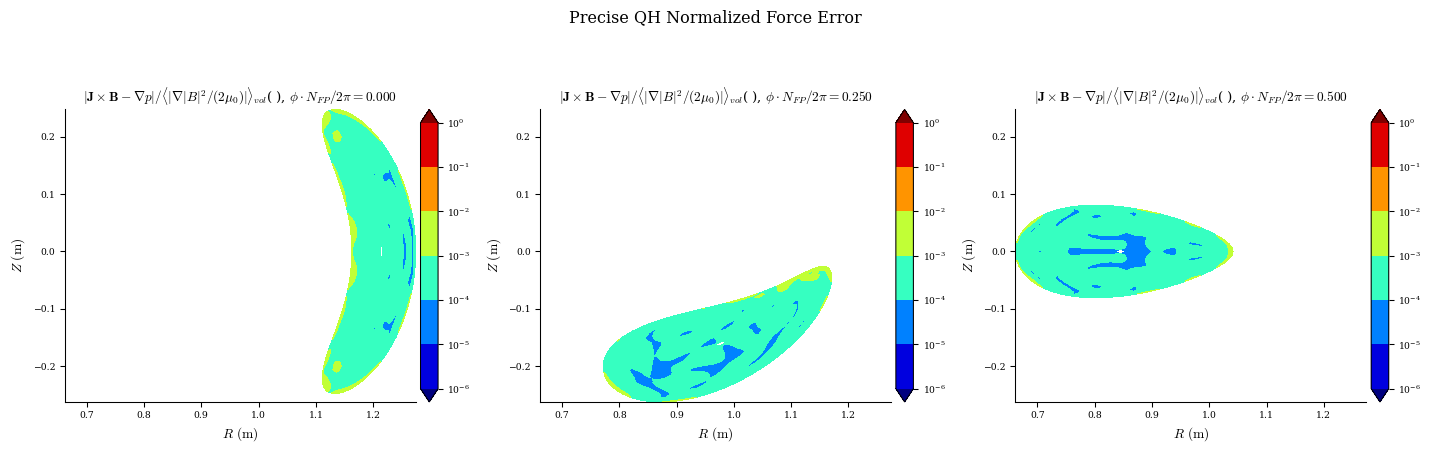

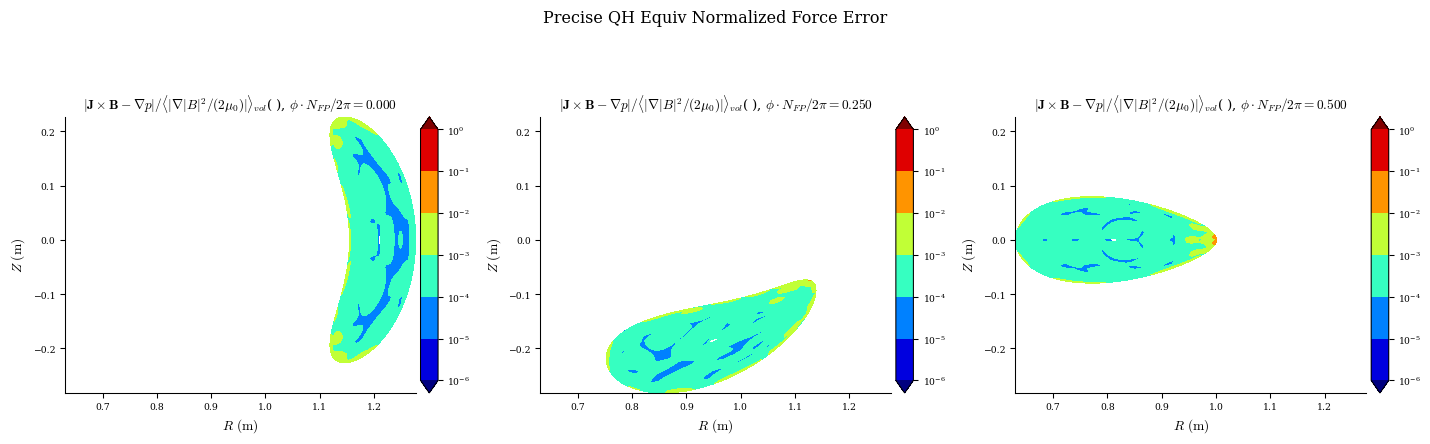

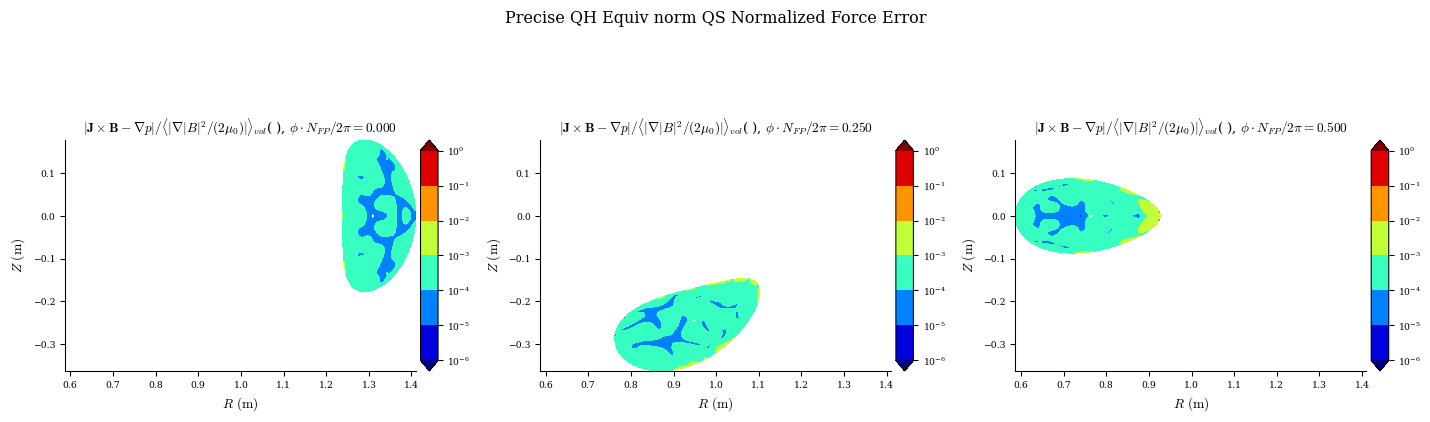

In [7]:
for eq in eqs:
    fig, ax = plot_section(eq, "|F|_normalized", phi=np.linspace(0, np.pi / eq.NFP, 3, endpoint=True), log=True)
    fig.suptitle(f"{labels[eqs.index(eq)]} Normalized Force Error")

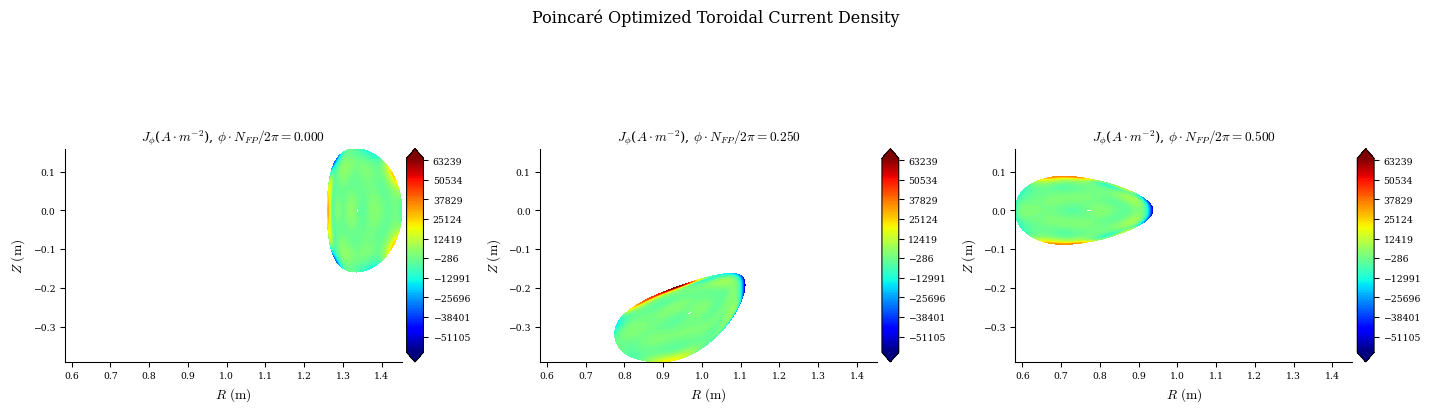

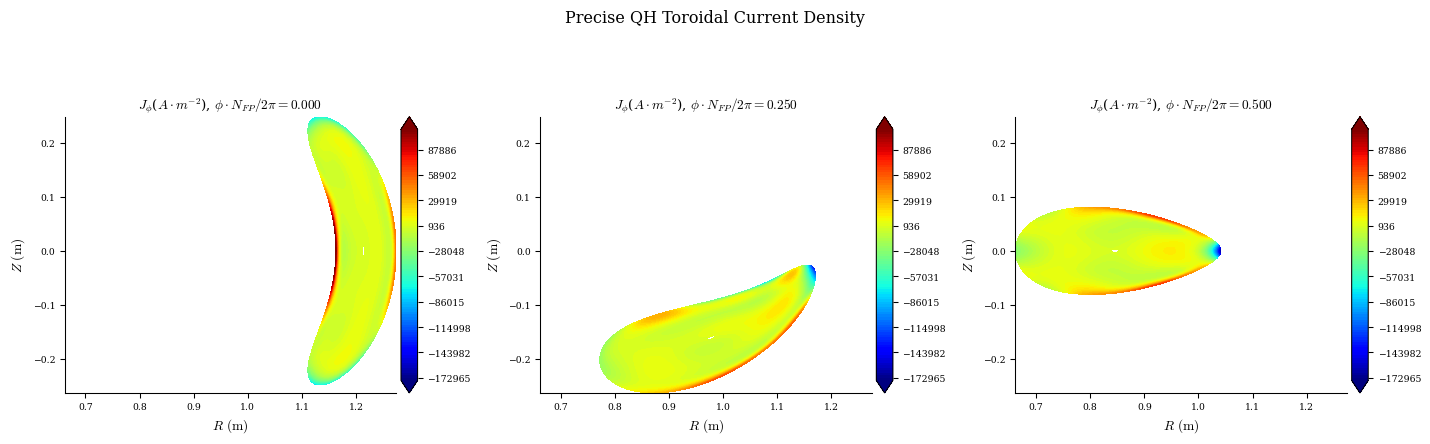

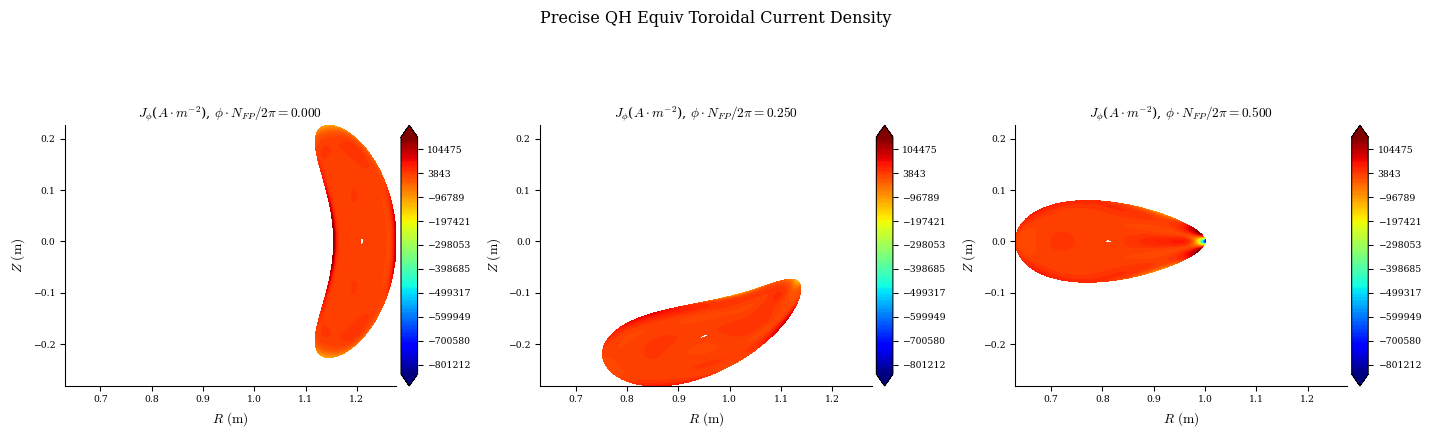

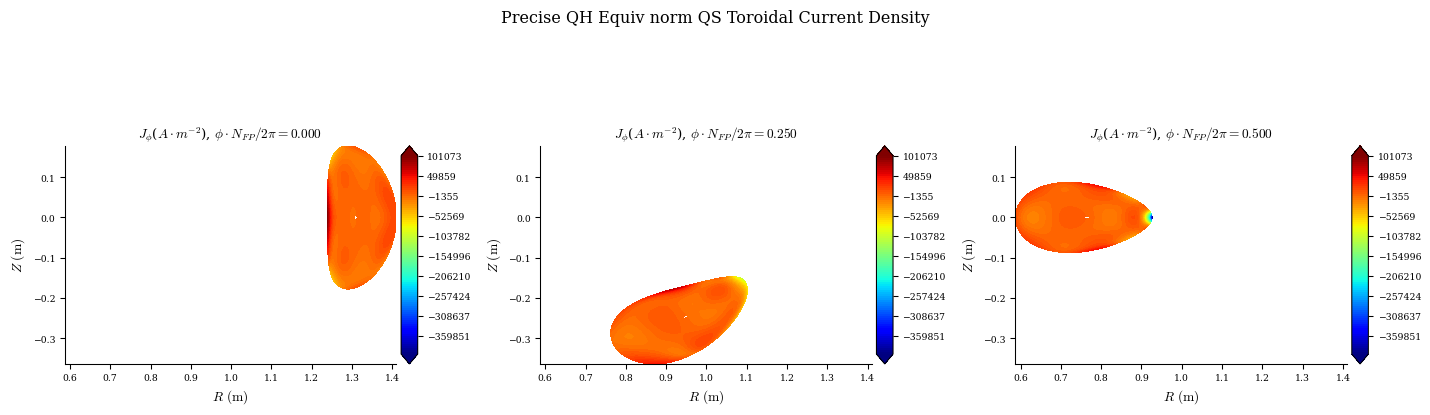

In [8]:
for eq in eqs:
    fig, ax = plot_section(eq, "J_phi", phi=np.linspace(0, np.pi / eq.NFP, 3, endpoint=True))
    fig.suptitle(f"{labels[eqs.index(eq)]} Toroidal Current Density")

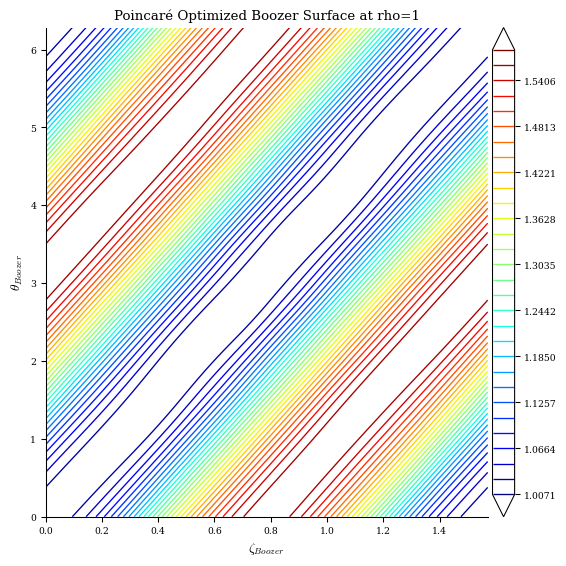

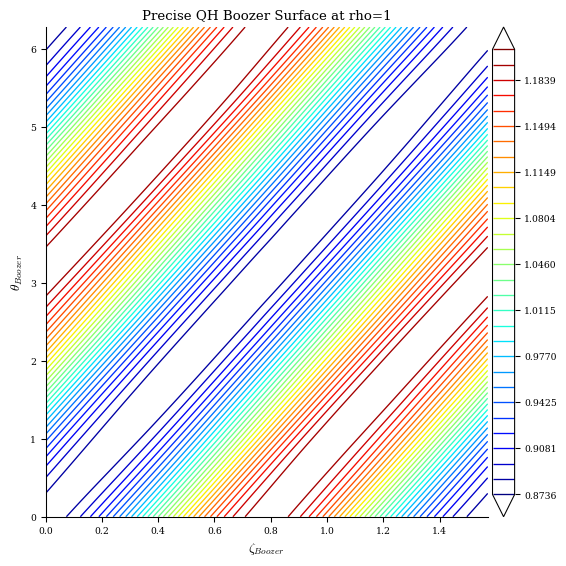

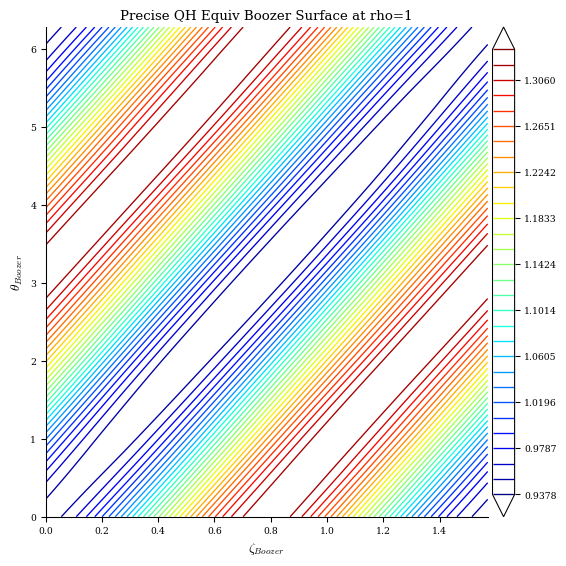

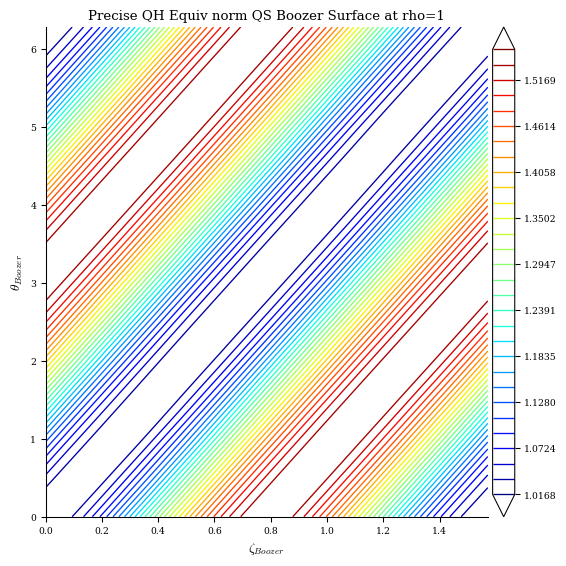

In [9]:
for eq in eqs:
    fig, ax = plot_boozer_surface(eq, rho=1)
    ax.set_title(f"{labels[eqs.index(eq)]} Boozer Surface at rho=1")

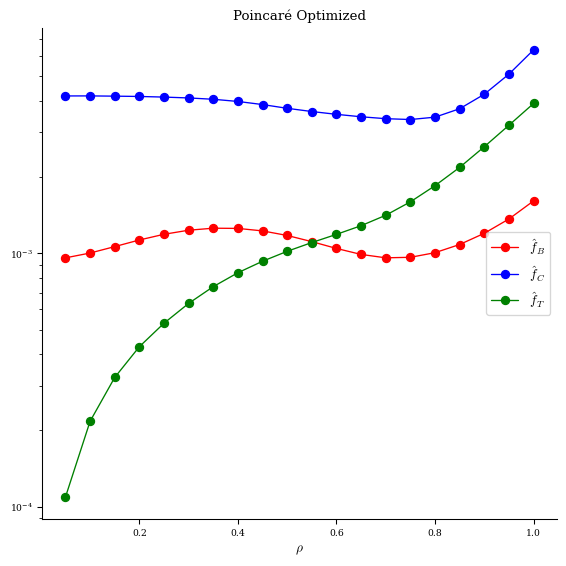

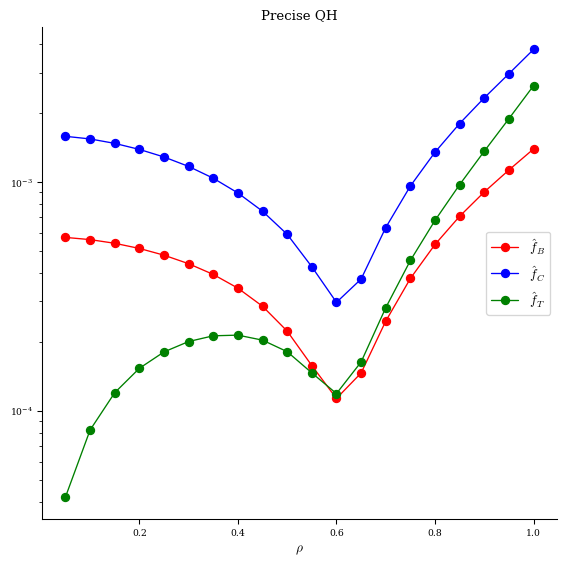

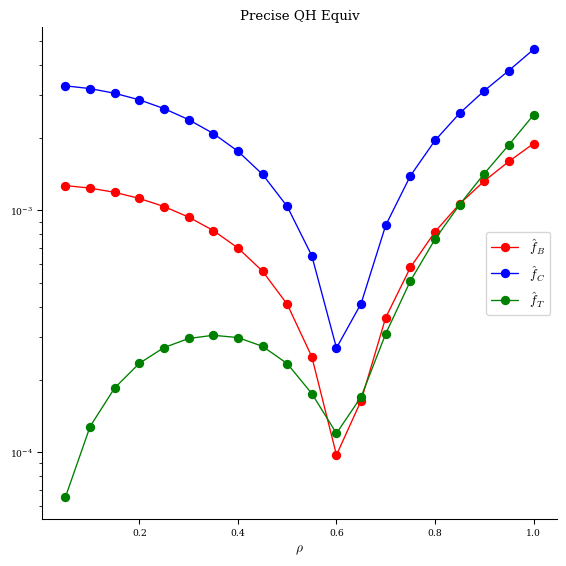

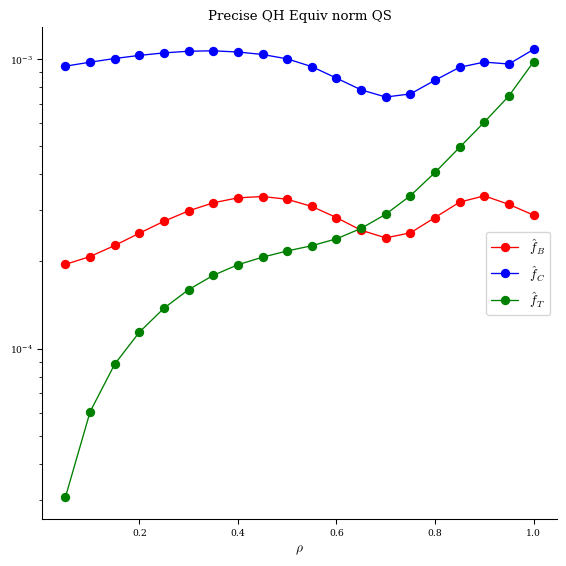

In [10]:
for eq in eqs:
    fig, ax = plot_qs_error(eq, helicity=(1, 4))
    ax.set_title(f"{labels[eqs.index(eq)]}")